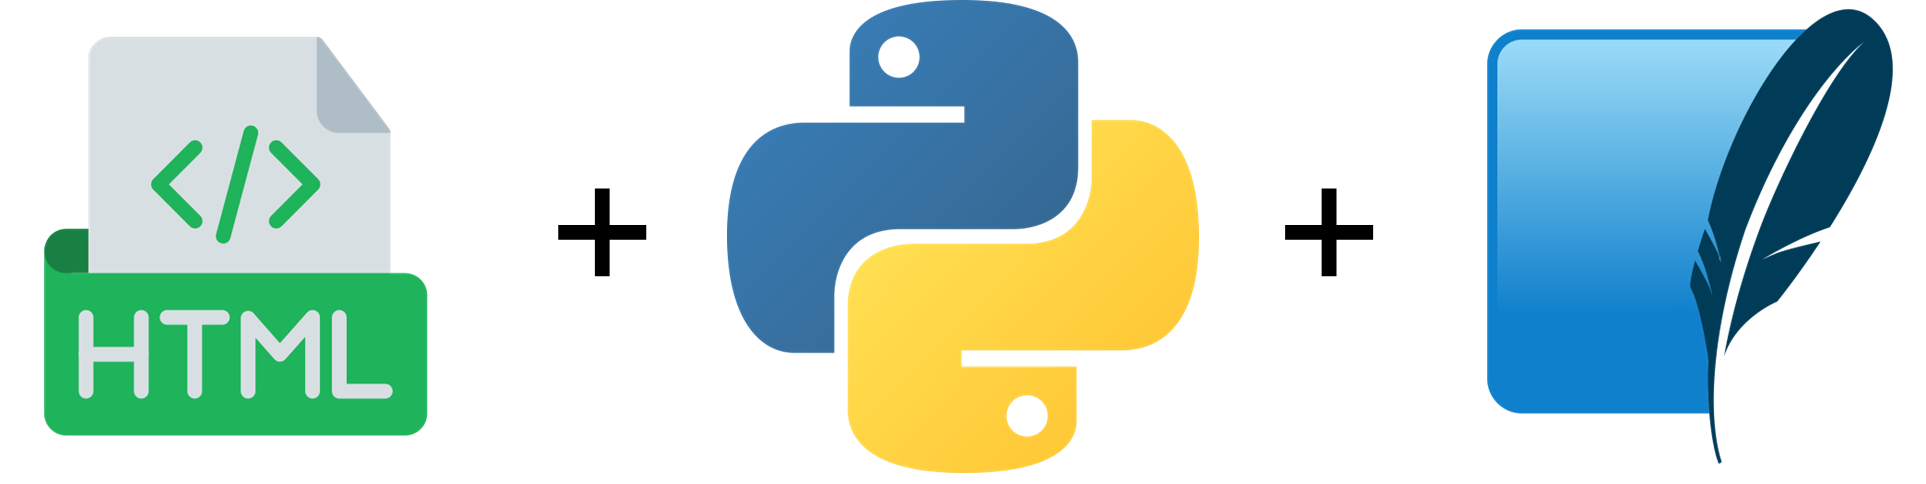

#### Passo 1: Instalar bibliotecas

In [1]:
%pip install requests
%pip install beautifulsoup4
%pip install sqlite3 
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


Note: you may need to restart the kernel to use updated packages.


#### Passo 2: Importar bibliotecas

In [2]:
import requests
from bs4 import BeautifulSoup
import sqlite3
import pandas as pd

#### Passo 3: Fromatar link de busca

Neste exemplo utilizaremos um site público de testes de scraping

http://books.toscrape.com (feito exatamente para treinar scraping).

In [3]:
# URL base para treinar web scraping
url = "https://books.toscrape.com/catalogue/category/books_1/page-1.html"

#### Passo 4: Determinar variáveis que para armazenamento
Neste exemplo, iremos utilizar:
- Título
- Preços
- Estoque

In [4]:
titulos, precos, estoque = [], [], []

#### Passo 5: Obter informações do link

In [5]:
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

#### Passo 5.1: Obter informações dos produtos

In [6]:
# Cada produto está dentro de article.product_pod
livros = soup.find_all("article", class_="product_pod")

In [7]:
livros[0].h3.a['title']

'A Light in the Attic'

In [8]:
# Preço
livros[0].find("p", class_="price_color").text.replace("Â£", "")

'51.77'

In [9]:
# Estoque
livros[0].find("p", class_="instock availability").text.strip() 
# A função strip()em Python serve para remover espaços em branco ou caracteres específicos do início e/ou fim de uma string

'In stock'

#### Passo 6: Coletar dados em escala
Neste exemplo, vamos coletar dados das 5 primeiras páginas

In [10]:
for page in range(1, 5): #pega páginas do 1 ao 4, pois a página 5 não existe, se quiser aumentar, é só colocar o número da última página + 1
    response = requests.get(f"https://books.toscrape.com/catalogue/category/books_1/page-{page}.html")
    soup = BeautifulSoup(response.text, "html.parser")
    
    # Cada produto está dentro de article.product_pod
    livros = soup.find_all("article", class_="product_pod")
    
    for livro in livros:
        # Título
        titulo = livro.h3.a["title"]
        titulos.append(titulo)
        
        # Preço
        preco = livro.find("p", class_="price_color").text.replace("Â£", "")
        precos.append(preco)
        
        # Estoque
        estoque_info = livro.find("p", class_="instock availability").text.strip()
        estoque.append(estoque_info)

print("Coleta concluída!")

Coleta concluída!


#### Passo 7: Criar DataFrame

In [11]:
df = pd.DataFrame({"titulo": titulos, "preco": precos, "estoque": estoque})
df.head()

,titulo,preco,estoque
0,A Light in the Attic,51.77,In stock
1,Tipping the Velvet,53.74,In stock
2,Soumission,50.10,In stock
3,Sharp Objects,47.82,In stock
4,Sapiens: A Brief History of Humankind,54.23,In stock


#### Passo 8: Criar Banco de Dados

In [12]:
conn = sqlite3.connect("livros.db") # criando banco de dados SQLite chamado livros.db
cursor = conn.cursor() # criando cursor para executar comandos SQL no banco de dados

#### Passo 9: DDL – Data Definition Language
DDL serve para **definir a estrutura do banco de dados**: criar, alterar e excluir tabelas.

- `CREATE` → cria tabelas e estruturas  
- `ALTER` → modifica a estrutura de tabelas  
- `DROP` → apaga tabelas ou bancos de dados  


In [13]:
cursor.execute("""
    CREATE TABLE IF NOT EXISTS livros (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    titulo TEXT NOT NULL,
    preco REAL NOT NULL,
    estoque TEXT NOT NULL
    );
""")
print('tabela criada com sucesso')

tabela criada com sucesso


##### 9.1: Listar todas tabelas do banco
Neste exemplo iremos utilizaremos a sintaxe `SELECT name FROM sqlite_master;`

- `sqlite_master` é uma tabela especial **interna** do SQLite que guarda **metadados** sobre o banco de dados: tabelas, índices, views e triggers
- `SELECT name` seleciona apenas o nome (`name`) dos objetos armazenados no `sqlite_master`

In [14]:
cursor.execute("""SELECT name FROM sqlite_master;""")
print(cursor.fetchall())#recupera todos resultados da última consulta SQL executada, que neste caso é a lista de tabelas no banco de dados.

[('livros',), ('sqlite_sequence',)]


Como pegar os resultados usando o método `fetch` (buscar)
- `fetchone()` Retorna apenas uma linha do resultado (a próxima disponível). Se não houver mais nada, retorna `None`
- `fetchmany(n)` Retorna as próximas n linhas do resultado.
- `fetchall()` Retorna todas as linhas restantes do resultado em uma lista de tuplas.

##### 9.2: Verificar o esquema da tabela (estrutura das colunas)

In [15]:
# fetch é buscar || fetchall é buscar todos os resultados da última consulta SQL executada (registros) || io '1' na última coluna identifica que a coluna é uma chave primária (primary key) e que os valores dessa coluna são únicos para cada registro na tabela.
cursor.execute("""PRAGMA table_info(livros); """) #pragma table_info() é um comando SQL específico do SQLite que retorna informações sobre as colunas de uma tabela específica. Ele fornece detalhes como o nome da coluna, o tipo de dados, se a coluna permite valores nulos, se é uma chave primária, entre outros.
for row in cursor.fetchall():
    print(row)

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'titulo', 'TEXT', 1, None, 0)
(2, 'preco', 'REAL', 1, None, 0)
(3, 'estoque', 'TEXT', 1, None, 0)


##### 9.3: Alterar tabela
Nesta etapa utilizaremos o comando `ALTER TABLE` informar a alteração da tabela e o comando `ADD COLUMN` para especificar a alteração
A saída mostra cada coluna da tabela:

(`cid` , `name` ,`type` , `notnull` , `dflt_value` , `pk`)

- `cid` índice da coluna
- `name` nome da coluna
- `type` tipo de dado (TEXT, REAL, etc.)
- `notnull` se pode ser NULL (0 = sim, 1 = não).
- `dflt_value` valor padrão (se houver)
- `pk` se é chave primária (1 = sim)

In [16]:
cursor.execute("""ALTER TABLE livros ADD COLUMN categoria TEXT; """)
conn.commit()
print("coluna categoria adicioada à tabela livros")

coluna categoria adicioada à tabela livros


##### 9.4: Verifica o equema da tabela após incluir coluna coluna

In [17]:
# fetch é buscar || fetchall é buscar todos os resultados da última consulta SQL executada (registros) || io '1' na última coluna identifica que a coluna é uma chave primária (primary key) e que os valores dessa coluna são únicos para cada registro na tabela.
cursor.execute("""PRAGMA table_info(livros); """) #pragma table_info() é um comando SQL específico do SQLite que retorna informações sobre as colunas de uma tabela específica. Ele fornece detalhes como o nome da coluna, o tipo de dados, se a coluna permite valores nulos, se é uma chave primária, entre outros.
for row in cursor.fetchall():
    print(row)

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'titulo', 'TEXT', 1, None, 0)
(2, 'preco', 'REAL', 1, None, 0)
(3, 'estoque', 'TEXT', 1, None, 0)
(4, 'categoria', 'TEXT', 0, None, 0)


##### 9.5: Remover uma coluna 
Nesta etapa utilizaremos o comando `ALTER TABLE` informar a alteração da tabela e o comando `DROP COLUMN` para especificar a alteração

In [18]:
cursor.execute("ALTER TABLE livros DROP COLUMN categoria")
conn.commit()
print('Coluna removida com sucesso!')

Coluna removida com sucesso!


##### 9.6: Verifica o equema da tabela após incluir coluna coluna

In [19]:
# fetch é buscar || fetchall é buscar todos os resultados da última consulta SQL executada (registros) || io '1' na última coluna identifica que a coluna é uma chave primária (primary key) e que os valores dessa coluna são únicos para cada registro na tabela.
cursor.execute("""PRAGMA table_info(livros); """) #pragma table_info() é um comando SQL específico do SQLite que retorna informações sobre as colunas de uma tabela específica. Ele fornece detalhes como o nome da coluna, o tipo de dados, se a coluna permite valores nulos, se é uma chave primária, entre outros.
for row in cursor.fetchall():
    print(row)

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'titulo', 'TEXT', 1, None, 0)
(2, 'preco', 'REAL', 1, None, 0)
(3, 'estoque', 'TEXT', 1, None, 0)


##### 9.7: Excluir tabela
Primeiro vamos criar uma tabela adicional

In [20]:
cursor.execute("""
    CREATE TABLE IF NOT EXISTS produtos (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        titulo TEXT NOT NULL,
        preco REAL NOT NULL,
        categoria TEXT NOT NULL
    );
""")

print('tabela produtos criada com sucesso!')

tabela produtos criada com sucesso!


##### Listar todas tabelas do banco

In [21]:
cursor.execute("""SELECT name FROM sqlite_master;""")
print(cursor.fetchall())#recupera todos resultados da última consulta SQL executada, que neste caso é a lista de tabelas no banco de dados.

[('livros',), ('sqlite_sequence',), ('produtos',)]


##### Remover tabela do banco

In [22]:
cursor.execute(""" DROP TABLE produtos; """)
conn.commit()
print("tabela produtos removida com sucesso!")

tabela produtos removida com sucesso!


##### Listar todas tabelas do banco

In [23]:
cursor.execute("""SELECT name FROM sqlite_master;""")
print(cursor.fetchall())#recupera todos resultados da última consulta SQL executada, que neste caso é a lista de tabelas no banco de dados.

[('livros',), ('sqlite_sequence',)]


#### Passo 10: DML – Data Manipulation Language

DML serve para **manipular os dados** dentro das tabelas:

- `INSERT` → inserir registros  
- `UPDATE` → atualizar registros  
- `DELETE` → excluir registros



##### 10.1 `INSERT` (inserir dados)

In [24]:
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO livros (titulo, preco, estoque) VALUES (?, ?, ?)
    """, (row['titulo'], row['preco'], row['estoque']))
conn.commit()  # salvando as alterações no banco de dados
print('Dados inseridos com sucesso!')
    #cursor é o objeto que executa os comandos SQL, e o commit() salva as alterações no banco de dados.
    # o underline serve para ignorar o índice do DataFrame, pois não precisamos dele para inserir os dados no banco. ou seja, o _ é uma convenção para indicar que a variável não será usada.

Dados inseridos com sucesso!


##### Verifica quantos registros foram inseridos

In [25]:
cursor.execute("""SELECT COUNT(*) FROM livros""")
cursor.fetchone() # ver quantos registros foram inseridos

(250,)

##### Verifica uma amostra dos registros inseridos

In [26]:
cursor.execute("""SELECT * FROM livros""")
cursor.fetchmany(5) # ver quantos registros foram inseridos

[(1, 'A Light in the Attic', 49.9, 'In stock'),
 (2, 'Tipping the Velvet', 53.74, 'In stock'),
 (3, 'Soumission', 50.1, 'In stock'),
 (4, 'Sharp Objects', 47.82, 'In stock'),
 (5, 'Sapiens: A Brief History of Humankind', 54.23, 'In stock')]

##### 10.2: `UPDATE` (atualizar dados)

In [27]:
cursor.execute("""UPDATE livros SET preco = 49.90 Where titulo = 'A Light in the Attic' ;""") #o preco vai pra 49.90 ONDE o titulo for igual a 'A light in the Attic'
conn.commit()
print("Valor do livro atualizado!")

Valor do livro atualizado!


##### Verifica uma amostra dos registros inseridos

In [28]:
cursor.execute("""SELECT * FROM livros""")
cursor.fetchmany(5) # ver quantos registros foram inseridos

[(1, 'A Light in the Attic', 49.9, 'In stock'),
 (2, 'Tipping the Velvet', 53.74, 'In stock'),
 (3, 'Soumission', 50.1, 'In stock'),
 (4, 'Sharp Objects', 47.82, 'In stock'),
 (5, 'Sapiens: A Brief History of Humankind', 54.23, 'In stock')]

##### 10.3: Inserir um novo registro no banco

In [29]:
cursor.execute("INSERT INTO livros (titulo, preco, estoque) VALUES ('Python for data analysis',99.99,'In stock')") #Estou inserindo na tabela livros, nas determinadas colunas
cursor.execute("INSERT INTO livros (titulo, preco, estoque) VALUES ('Como vender makonha kkkkkkkkkkkk',99.99,'In stock')")
cursor.execute("INSERT INTO livros (titulo, preco, estoque) VALUES ('Como sequestrar o cara que vende makonha',99.99,'In stock')")
cursor.execute("INSERT INTO livros (titulo, preco, estoque) VALUES ('Como tirei o cara que vende makonha do cativeiro',99.99,'In stock')")
cursor.execute("INSERT INTO livros (titulo, preco, estoque) VALUES ('Python from corinthianos ',99.99,'In stock')")

##### Verifica quantos registros existem no banco

In [30]:
cursor.execute(""" SELECT COUNT(*) FROM LIVROS""")
cursor.fetchone()

(255,)

In [31]:
cursor.execute(""" SELECT * FROM livros ORDER BY id DESC; """)
cursor.fetchmany(5)

[(255, 'Python from corinthianos ', 99.99, 'In stock'),
 (254, 'Como tirei o cara que vende makonha do cativeiro', 99.99, 'In stock'),
 (253, 'Como sequestrar o cara que vende makonha', 99.99, 'In stock'),
 (252, 'Como vender makonha kkkkkkkkkkkk', 99.99, 'In stock'),
 (251, 'Python for data analysis', 99.99, 'In stock')]

##### Verifica uma amostra dos últimos registros inseridos

In [32]:
cursor.execute(""" SELECT * FROM livros ORDER BY id DESC; """)
cursor.fetchmany(5)

[(255, 'Python from corinthianos ', 99.99, 'In stock'),
 (254, 'Como tirei o cara que vende makonha do cativeiro', 99.99, 'In stock'),
 (253, 'Como sequestrar o cara que vende makonha', 99.99, 'In stock'),
 (252, 'Como vender makonha kkkkkkkkkkkk', 99.99, 'In stock'),
 (251, 'Python for data analysis', 99.99, 'In stock')]

##### 10.4: `DELETE` (exclui registros)

In [33]:
cursor.execute("DELETE FROM livros WHERE titulo = 'Python for database' ;")
conn.commit() # identificar
print("registro removido")  

registro removido


##### Verifica uma amostra dos últimos registros inseridos

In [34]:
cursor.execute("SELECT * FROM livros ORDER BY id DESC")

#### Passo 11: DQL serve para **consultar dados** no banco:

- `SELECT`  
- `WHERE`  
- `ORDER BY`  
- `GROUP BY`  
- Funções de agregação (`COUNT`, `AVG`, `MAX`, `MIN`, `SUM`) 

##### Consulta simples com `fetchone`

In [35]:
cursor.execute("SELECT * FROM livros")
cursor.fetchone()

(1, 'A Light in the Attic', 49.9, 'In stock')

##### Consulta simples com `fetchmany()`

In [36]:
cursor.execute("SELECT * FROM livros")
cursor.fetchmany(4)

[(1, 'A Light in the Attic', 49.9, 'In stock'),
 (2, 'Tipping the Velvet', 53.74, 'In stock'),
 (3, 'Soumission', 50.1, 'In stock'),
 (4, 'Sharp Objects', 47.82, 'In stock')]

##### Consulta simples com `fetchall()`

In [37]:
cursor.execute("SELECT * FROM livros ORDER BY titulo DESC")
cursor.fetchall()

[(40, "You can't bury them all: Poems", 33.63, 'In stock'),
 (125, "You can't bury them all: Poems", 33.63, 'In stock'),
 (210, "You can't bury them all: Poems", 33.63, 'In stock'),
 (29,
  'Worlds Elsewhere: Journeys Around Shakespeareâ\x80\x99s Globe',
  40.3,
  'In stock'),
 (114,
  'Worlds Elsewhere: Journeys Around Shakespeareâ\x80\x99s Globe',
  40.3,
  'In stock'),
 (199,
  'Worlds Elsewhere: Journeys Around Shakespeareâ\x80\x99s Globe',
  40.3,
  'In stock'),
 (45, 'Without Borders (Wanderlove #1)', 45.07, 'In stock'),
 (130, 'Without Borders (Wanderlove #1)', 45.07, 'In stock'),
 (215, 'Without Borders (Wanderlove #1)', 45.07, 'In stock'),
 (46, 'When We Collided', 31.77, 'In stock'),
 (131, 'When We Collided', 31.77, 'In stock'),
 (216, 'When We Collided', 31.77, 'In stock'),
 (47, 'We Love You, Charlie Freeman', 50.27, 'In stock'),
 (132, 'We Love You, Charlie Freeman', 50.27, 'In stock'),
 (217, 'We Love You, Charlie Freeman', 50.27, 'In stock'),
 (30, 'Wall and Piece', 44.

#### `WHERE`
##### Consulta com filtro: Livros com preço abaixo de 20 

In [38]:
cursor.execute(""" SELECT id, titulo, preco FROM livros WHERE preco<20 """)
cursor.fetchall()

[(8,
  'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull',
  17.93),
 (11, 'Starving Hearts (Triangular Trade Trilogy, #1)', 13.99),
 (13, 'Set Me Free', 17.46),
 (21, 'In Her Wake', 12.84),
 (31, 'The Four Agreements: A Practical Guide to Personal Freedom', 17.66),
 (35, "Sophie's World", 15.94),
 (37, 'Maude (1883-1993):She Grew Up with the country', 18.02),
 (38, 'In a Dark, Dark Wood', 19.63),
 (48, 'Untitled Collection: Sabbath Poems 2014', 14.27),
 (50, 'Unicorn Tracks', 18.78),
 (52, 'Tsubasa: WoRLD CHRoNiCLE 2 (Tsubasa WoRLD CHRoNiCLE #2)', 16.28),
 (54, 'This One Summer', 19.49),
 (55, 'Thirst', 17.27),
 (56, 'The Torch Is Passed: A Harding Family Story', 19.09),
 (65,
  'The Life-Changing Magic of Tidying Up: The Japanese Art of Decluttering and Organizing',
  16.77),
 (72,
  'The Age of Genius: The Seventeenth Century and the Birth of the Modern Mind',
  19.73),
 (79,
  'Reskilling America: Learning to Labor in the Twenty-First Century'

#### `ORDER BY`
##### Consulta com ordenação: Top 5 livros mais caros 

In [39]:
cursor.execute(""" SELECT titulo,preco FROM livros ORDER BY preco DESC""")
cursor.fetchmany(5)

[('Python for data analysis', 99.99),
 ('Como vender makonha kkkkkkkkkkkk', 99.99),
 ('Como sequestrar o cara que vende makonha', 99.99),
 ('Como tirei o cara que vende makonha do cativeiro', 99.99),
 ('Python from corinthianos ', 99.99)]

#### `GROUP BY`
##### Consulta com agregação: Quantidade de livros por situação de estoque 

In [40]:
cursor.execute("INSERT INTO livros (titulo, preco, estoque) VALUES ('Python from makonha sellers',99.99,'Out of stock')")
cursor.execute("INSERT INTO livros (titulo, preco, estoque) VALUES ('Python from manoel gomes ',99.99,'Out of stock')")

In [41]:
cursor.execute(""" SELECT estoque, COUNT (*) FROM livros GROUP BY estoque """) #selec
cursor.fetchall()


[('In stock', 255), ('Out of stock', 2)]

In [43]:
cursor.execute(" SELECT FROM * livros WHERE estoque = 'Out of stock' ")
cursor.fetchall()

OperationalError: near "FROM": syntax error

#### `DISTINCT`
##### Consulta com filtro: Contagem de dados distintos

In [ ]:
cursor.execute(" SELECT COUNT(DISTINCT titulo) FROM livros; ") #Puxando registros únicos
cursor.fetchall()

[(87,)]

#### `HAVING COUNT(*)`
##### Consulta com filtro: Contagem de dados repetidos

In [ ]:
###Contagem de dados repetidos, qual registro que é repetido
cursor.execute("SELECT preco FROM livros GROUP BY preco HAVING COUNT (*)>1;")
cursor.fetchall()

[(44.18,), (99.99,)]

#### `AVG`
##### Consulta com agregação: Valor médio dos livros 

In [ ]:
cursor.execute(""" SELECT AVG(preco) FROM livros """)
cursor.fetchone()[0]

40.85896551724138

##### Consulta com agregação: Valor médio dos livros  (com arredondamento)

In [ ]:
cursor.execute(""" SELECT ROUND(AVG(preco),2) FROM livros """)
cursor.fetchone()

(40.86,)

#### `MAX`
##### Consulta com agregação: Maior valor entre os livros `MAX`

In [ ]:
cursor.execute(""" SELECT MAX(preco) FROM livros """)
cursor.fetchone()

(99.99,)

#### `MIN`
##### Consulta com agregação: Menor valor entre os livros 

In [ ]:
cursor.execute(""" SELECT MIN(preco) FROM livros """)
cursor.fetchone()

(12.84,)

#### `SUM`
##### Consulta com agregação: Soma do valor dos livros

In [ ]:
cursor.execute(""" SELECT SUM(preco) FROM livros """)
cursor.fetchone()

(6909.48,)

##### Consulta com agregação: Soma do valor dos livros em estoque

In [ ]:
cursor.execute("SELECT SUM(preco) FROM livros WHERE estoque = 'Out of stock';")
cursor.fetchone()

(199.98,)

##### Consulta com agregação: Soma do valor dos livros sem estoque

In [ ]:
cursor.execute(""" SELECT MAX(preco), AVG(preco), MIN(preco) FROM livros; """)
maximo,medio,minimo = cursor.fetchone()
print(f'preço máximo {maximo}, preço médio {medio}, preço mínimo: {minimo}')

preço máximo 99.99, preço médio 40.17139534883721, preço mínimo: 12.84


##### Consulta de multiplos valores: Valor Máximo, Medio e Mínimo

In [ ]:
cursor.execute(""" SELECT MAX(preco), AVG(preco), MIN(preco) FROM livros; """)
maximo,medio,minimo = cursor.fetchone()
print(f'preço máximo {maximo}, preço médio {medio}, preço mínimo: {minimo}')

preço máximo 99.99, preço médio 40.17139534883721, preço mínimo: 12.84


##### Consulta com Ranking por Preço

In [44]:
cursor.execute("SELECT RANK() OVER (ORDER BY preco DESC) AS rank, titulo, preco FROM livros;")
cursor.fetchall()

[(1, 'Python for data analysis', 99.99),
 (1, 'Como vender makonha kkkkkkkkkkkk', 99.99),
 (1, 'Como sequestrar o cara que vende makonha', 99.99),
 (1, 'Como tirei o cara que vende makonha do cativeiro', 99.99),
 (1, 'Python from corinthianos ', 99.99),
 (1, 'Python for data analysis', 99.99),
 (1, 'Como vender makonha kkkkkkkkkkkk', 99.99),
 (1, 'Como sequestrar o cara que vende makonha', 99.99),
 (1, 'Como tirei o cara que vende makonha do cativeiro', 99.99),
 (1, 'Python from corinthianos ', 99.99),
 (1, 'Python for data analysis', 99.99),
 (1, 'Como vender makonha kkkkkkkkkkkk', 99.99),
 (1, 'Como sequestrar o cara que vende makonha', 99.99),
 (1, 'Como tirei o cara que vende makonha do cativeiro', 99.99),
 (1, 'Python from corinthianos ', 99.99),
 (1, 'Python from makonha sellers', 99.99),
 (1, 'Python from manoel gomes ', 99.99),
 (18, 'The Death of Humanity: and the Case for Life', 58.11),
 (18, 'The Death of Humanity: and the Case for Life', 58.11),
 (18, 'The Death of Humanity

#### 12: JOINS – Relacionando tabelas

JOINS permitem **combinar dados de várias tabelas**.  
Vamos criar outras tabelas para exemplificar.

##### 12.1 Criar tabela de vendas

In [ ]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    livro_id INTEGER,
    data_venda DATE,
    quantidade INTEGER,
    valor_total REAL,
    cliente TEXT,
    FOREIGN KEY (livro_id) REFERENCES livros(id)
);
''')
conn.commit()
print("Tabela criadas com sucesso!")

Tabela criadas com sucesso!


##### Verifica o esquema da tabela (estrutura das colunas)

In [46]:
cursor.execute("""PRAGMA table_info(vendas); """) 
for row in cursor.fetchall():
    print(row)

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'livro_id', 'INTEGER', 0, None, 0)
(2, 'data_venda', 'DATE', 0, None, 0)
(3, 'quantidade', 'INTEGER', 0, None, 0)
(4, 'valor_total', 'REAL\n    cliente TEXT', 0, None, 0)


##### 12.2: Inserir dados de exemplo

In [54]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas (
id INTEGER PRIMARY KEY AUTOINCREMENT,
livro_id INTEGER,
data_venda DATE,
quantidade INTEGER,
valor_total REAL,
cliente TEXT,
FOREIGN KEY (livro_id) REFERENCES livros(id)
);
''')
conn.commit()
print("Tabela criadas com sucesso!")




vendas_exemplo = [
(1, '2025-01-15', 2, 'João Silva'),
(5, '2025-01-16', 1, 'Maria Santos'),
(10, '2025-01-17', 3, 'Pedro Costa'),
(15, '2025-01-18', 1, 'Ana Oliveira'),
(20, '2025-01-19', 2, 'Carlos Lima'),
(25, '2025-01-20', 1, 'Juliana Pereira'),
(30, '2025-01-21', 2, 'Roberto Alves'),
(35, '2025-01-22', 1, 'Fernanda Dias'),
(40, '2025-01-23', 3, 'Ricardo Martins'),
(45, '2025-01-24', 1, 'Patrícia Souza')
]

for livro_id, data, quantidade, cliente in vendas_exemplo:
    # Buscar preço
    cursor.execute("SELECT preco FROM livros WHERE id = ?", (livro_id,))
    resultado = cursor.fetchone()
    valor_total = round(resultado[0] * quantidade,2)

cursor.execute('''
    INSERT INTO vendas (livro_id, data_venda, quantidade, valor_total, cliente) 
    VALUES (?, ?, ?, ?, ?)
    ''', (livro_id, data, quantidade, valor_total, cliente))

conn.commit()
print(f"{len(vendas_exemplo)} vendas inseridas com sucesso!")


Tabela criadas com sucesso!
10 vendas inseridas com sucesso!


##### Verifica dados inseridos 

In [55]:
cursor.execute("SELECT * FROM vendas")
cursor.fetchall()

[(1, 45, '2025-01-24', 1, 45.07, 'Patrícia Souza')]

##### 12.3: Exemplos de JOINs com a tabela existente

In [56]:
cursor.execute('drop table vendas')

#### 13: Transações – BEGIN, COMMIT e ROLLBACK

Uma transação é um conjunto de operações que devem ser executadas juntas.  

- `BEGIN` → inicia a transação  
- `COMMIT` → confirma as alterações  
- `ROLLBACK` → desfaz as alterações (caso de erro)  

#### Passo 13: Encerra conexão com banco de dados